In [2]:
import pandas as pd 
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv('/home/uplong/Documents/DSU-analytics-comp-2026/data/grouped_by_year_month_added_c_x.csv', parse_dates=['Date'])
# df = df.set_index('Date')
df = df.drop(['total_encounters_c'], axis=1)

# Add features

## Lag Features

In [141]:
def add_lags(df, target, lags):
    for lag in lags:
        df[f"{target}_lag_{lag}"] = df[target].shift(lag)
    return df

Infering to the ACF and PACF plots in the ARIMA notebook we start by including lags 1 and 12 for the previous month and the same month one year ago

In [142]:
lags = [1, 12]
df = add_lags(df, "total_encounters", lags)

## Rolling window features

In [143]:
def add_rolling_features(df, target, windows):
    for w in windows:
        df[f"{target}_roll_mean_{w}"] = df[target].shift(1).rolling(w).mean()
        df[f"{target}_roll_std_{w}"] = df[target].shift(1).rolling(w).std()
    return df


In [144]:
windows = [6, 12, 24]
df = add_rolling_features(df, 'total_encounters', windows)

## Time based features

In [145]:
def add_time_features(df):
    # df["dayofweek"] = df["Date"].dt.dayofweek
    # df["day"] = df["Date"].dt.day
    df["month"] = df["Date"].dt.month
    # df["weekofyear"] = df["Date"].dt.isocalendar().week.astype(int)
    return df

In [146]:
df = add_time_features(df)

## Train/Test split

In [147]:
train = df[df["Date"] < "2025-01-01"]
test = df[df["Date"] >= "2025-01-01"]

X_train = train.drop(columns=["Date", "total_encounters"])
y_train = train["total_encounters"]

X_test = test.drop(columns=["Date", "total_encounters"])
y_test = test["total_encounters"]


## Train model

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=int(1e5),
    max_depth=32,
    learning_rate=1e-4,
    subsample=0.9,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    early_stopping_rounds=100,
    random_state=7,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)
# 487.82 for smoothened 2020 lr=0.05
# 475.77 for flagged covid lr=0.05

[0]	validation_0-rmse:1255.96122
[100]	validation_0-rmse:1247.19047
[200]	validation_0-rmse:1238.42483
[300]	validation_0-rmse:1230.32526
[400]	validation_0-rmse:1221.91074
[500]	validation_0-rmse:1214.14820
[600]	validation_0-rmse:1205.42312
[700]	validation_0-rmse:1197.31855
[800]	validation_0-rmse:1189.41529
[900]	validation_0-rmse:1181.52833
[1000]	validation_0-rmse:1173.45444
[1100]	validation_0-rmse:1165.30375
[1200]	validation_0-rmse:1157.44277
[1300]	validation_0-rmse:1149.56711
[1400]	validation_0-rmse:1142.07102
[1500]	validation_0-rmse:1134.38218
[1600]	validation_0-rmse:1126.66122
[1700]	validation_0-rmse:1119.41483
[1800]	validation_0-rmse:1111.85837
[1900]	validation_0-rmse:1104.54779
[2000]	validation_0-rmse:1097.29485
[2100]	validation_0-rmse:1090.19547
[2200]	validation_0-rmse:1083.31330
[2300]	validation_0-rmse:1076.35542
[2400]	validation_0-rmse:1069.71378
[2500]	validation_0-rmse:1062.86943
[2600]	validation_0-rmse:1056.03523
[2700]	validation_0-rmse:1049.34345
[280

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",100
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [173]:
preds = model.predict(X_test)

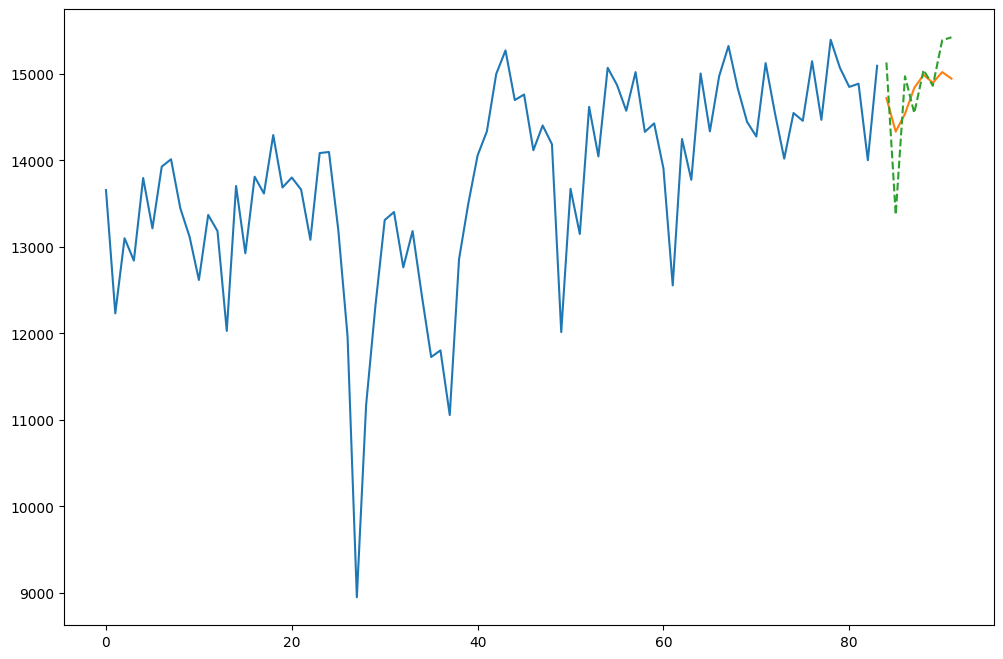

In [174]:
plt.figure(figsize=(12,8))
plt.plot(train.total_encounters)
plt.plot(X_test.index, model.predict(X_test))
plt.plot(y_test, linestyle='--')
plt.show()

In [155]:
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def mae(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred))) 

In [175]:
mape(y_test, preds)

np.float64(2.6112821195286697)